<a href="https://colab.research.google.com/github/Kunal537-gif/Kunal537-gif/blob/main/CBSOT_PROJECT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

***CHURN PREDICTION SYSTEM***

EDA

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df=pd.read_excel("Telco_customer_churn.xlsx")

In [ ]:
df

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,2569-WGERO,1,United States,California,Landers,92285,"34.341737, -116.539416",34.341737,-116.539416,Female,...,Two year,Yes,Bank transfer (automatic),21.15,1419.4,No,0,45,5306,NaN
7039,6840-RESVB,1,United States,California,Adelanto,92301,"34.667815, -117.536183",34.667815,-117.536183,Male,...,One year,Yes,Mailed check,84.80,1990.5,No,0,59,2140,NaN
7040,2234-XADUH,1,United States,California,Amboy,92304,"34.559882, -115.637164",34.559882,-115.637164,Female,...,One year,Yes,Credit card (automatic),103.20,7362.9,No,0,71,5560,NaN
7041,4801-JZAZL,1,United States,California,Angelus Oaks,92305,"34.1678, -116.86433",34.167800,-116.864330,Female,...,Month-to-month,Yes,Electronic check,29.60,346.45,No,0,59,2793,NaN


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [ ]:
df['Churn Label'].value_counts()

,count
Churn Label,
No,5174
Yes,1869


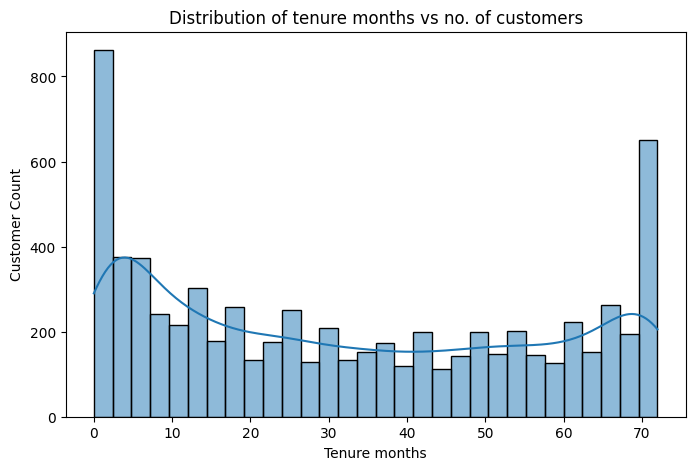

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df['Tenure Months'], bins = 30, kde=True)
plt.xlabel('Tenure months')
plt.ylabel('Customer Count')
plt.title('Distribution of tenure months vs no. of customers')
plt.show()

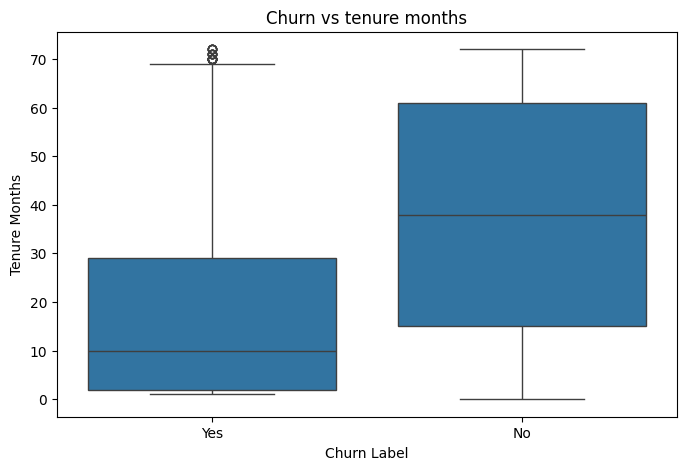

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Churn Label', y='Tenure Months', data=df)
plt.xlabel('Churn Label')
plt.ylabel('Tenure Months')
plt.title('Churn vs tenure months')
plt.show()

In [ ]:
df[df['Churn Label']=='Yes']['Monthly Charges'].quantile([0.25,0.5,0.75])

,Monthly Charges
0.25,56.15
0.50,79.65
0.75,94.20


In [ ]:
df[df['Churn Label']=='No']['Monthly Charges'].quantile([0.25,0.5,0.75])

,Monthly Charges
0.25,25.100
0.50,64.425
0.75,88.400


In [ ]:
df['Monthly Charges'].describe()

,Monthly Charges
count,7043.000000
mean,64.761692
std,30.090047
min,18.250000
25%,35.500000
50%,70.350000
75%,89.850000
max,118.750000


In [ ]:
df['Monthly Charges'].quantile([0.25,0.5,0.75])

,Monthly Charges
0.25,35.50
0.50,70.35
0.75,89.85


In [ ]:
df['Monthly Charges'].describe()

,Monthly Charges
count,7043.000000
mean,64.761692
std,30.090047
min,18.250000
25%,35.500000
50%,70.350000
75%,89.850000
max,118.750000


In [ ]:
df['Contract'].unique()

array(['Month-to-month', 'Two year', 'One year'], dtype=object)

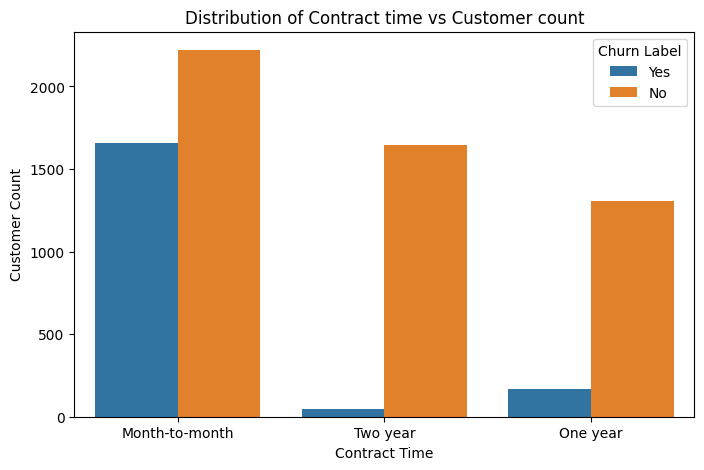

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(x='Contract', hue ='Churn Label', data=df)
plt.xlabel('Contract Time')
plt.ylabel('Customer Count')
plt.title('Distribution of Contract time vs Customer count')
plt.show()

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [ ]:
df['Internet Service'].unique()

array(['DSL', 'Fiber optic', 'No'], dtype=object)

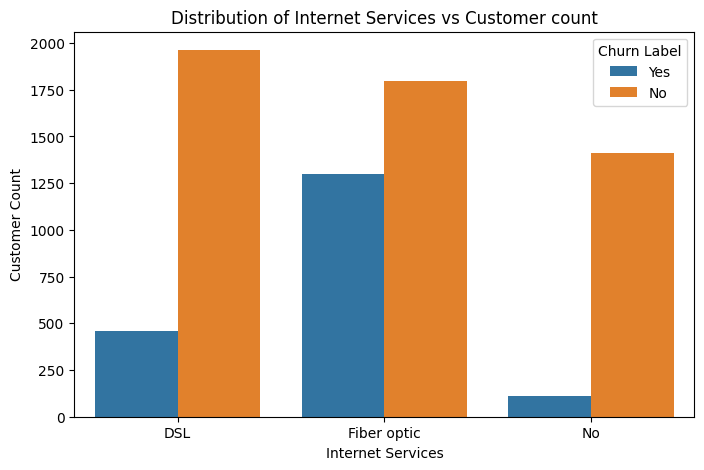

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(x='Internet Service', hue ='Churn Label', data=df)
plt.xlabel('Internet Services')
plt.ylabel('Customer Count')
plt.title('Distribution of Internet Services vs Customer count')
plt.show()

In [ ]:
df['Payment Method'].unique()

array(['Mailed check', 'Electronic check', 'Bank transfer (automatic)',
       'Credit card (automatic)'], dtype=object)

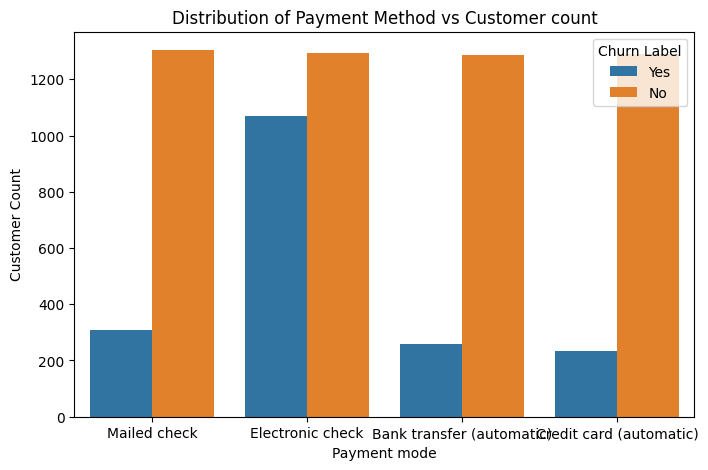

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(x='Payment Method', hue ='Churn Label', data=df)
plt.xlabel('Payment mode')
plt.ylabel('Customer Count')
plt.title('Distribution of Payment Method vs Customer count')
plt.show()

In [ ]:
df['Tech Support'].unique()

array(['No', 'Yes', 'No internet service'], dtype=object)

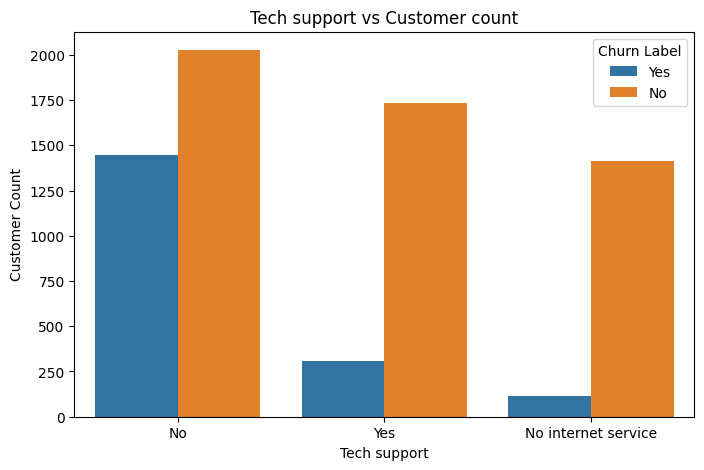

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(x='Tech Support', hue ='Churn Label', data=df)
plt.xlabel('Tech support')
plt.ylabel('Customer Count')
plt.title('Tech support vs Customer count')
plt.show()

In [ ]:
avg_tenure=df.groupby('Churn Label')['Tenure Months'].mean()

In [ ]:
avg_tenure

,Tenure Months
Churn Label,
No,37.569965
Yes,17.979133


In [ ]:
numerical_cols=['Tenure Months','Monthly Charges','Churn Value','Churn Score','CLTV']
correlation_matrix=df[numerical_cols].corr()

In [ ]:
correlation_matrix

,Tenure Months,Monthly Charges,Churn Value,Churn Score,CLTV
Tenure Months,1.000000,0.247900,-0.352229,-0.224987,0.396406
Monthly Charges,0.247900,1.000000,0.193356,0.133754,0.098693
Churn Value,-0.352229,0.193356,1.000000,0.664897,-0.127463
Churn Score,-0.224987,0.133754,0.664897,1.000000,-0.079782
CLTV,0.396406,0.098693,-0.127463,-0.079782,1.000000


In [ ]:
contract_churn=pd.crosstab(df['Contract'],df['Churn Label'])
contract_churn

Churn Label,No,Yes
Contract,,
Month-to-month,2220,1655
One year,1307,166
Two year,1647,48


In [ ]:
contract_churn=pd.crosstab(df['Contract'],df['Churn Label'],normalize='index')
contract_churn

Churn Label,No,Yes
Contract,,
Month-to-month,0.572903,0.427097
One year,0.887305,0.112695
Two year,0.971681,0.028319


DATA CLEANING

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [ ]:
df['Total Charges']

,Total Charges
0,108.15
1,151.65
2,820.5
3,3046.05
4,5036.3
...,...
7038,1419.4
7039,1990.5
7040,7362.9
7041,346.45


In [ ]:
df['Total Charges']=pd.to_numeric(df['Total Charges'],errors='coerce')

In [ ]:
df['Total Charges']

,Total Charges
0,108.15
1,151.65
2,820.50
3,3046.05
4,5036.30
...,...
7038,1419.40
7039,1990.50
7040,7362.90
7041,346.45


In [ ]:
df['Total Charges'].isnull().sum()

np.int64(11)

In [ ]:
df[df['Total Charges'].isnull()]['Tenure Months']

,Tenure Months
2234,0
2438,0
2568,0
2667,0
2856,0
4331,0
4687,0
5104,0
5719,0
6772,0


In [ ]:
df['Total Charges']=df['Total Charges'].fillna(0)

In [ ]:
df['Total Charges'].isnull().sum()

np.int64(0)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [ ]:
df.shape

(7043, 33)

In [ ]:
drop_columns=['Count','Country','State','Zip Code','Lat Long','Latitude','Longitude','Churn Label','Churn Score','CLTV','Churn Reason']

In [ ]:
df=df.drop(columns=drop_columns)

In [ ]:
df.shape

(7043, 22)

In [ ]:
df_encoded=pd.get_dummies(df,drop_first=True)

In [ ]:
df_encoded.head()

,Tenure Months,Monthly Charges,Total Charges,Churn Value,CustomerID_0003-MKNFE,CustomerID_0004-TLHLJ,CustomerID_0011-IGKFF,CustomerID_0013-EXCHZ,CustomerID_0013-MHZWF,CustomerID_0013-SMEOE,...,Streaming TV_No internet service,Streaming TV_Yes,Streaming Movies_No internet service,Streaming Movies_Yes,Contract_One year,Contract_Two year,Paperless Billing_Yes,Payment Method_Credit card (automatic),Payment Method_Electronic check,Payment Method_Mailed check
0,2,53.85,108.15,1,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,True
1,2,70.70,151.65,1,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,True,False
2,8,99.65,820.50,1,False,False,False,False,False,False,...,False,True,False,True,False,False,True,False,True,False
3,28,104.80,3046.05,1,False,False,False,False,False,False,...,False,True,False,True,False,False,True,False,True,False
4,49,103.70,5036.30,1,False,False,False,False,False,False,...,False,True,False,True,False,False,True,False,False,False


In [ ]:
df_encoded.shape

(7043, 8201)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   City               7043 non-null   object 
 2   Gender             7043 non-null   object 
 3   Senior Citizen     7043 non-null   object 
 4   Partner            7043 non-null   object 
 5   Dependents         7043 non-null   object 
 6   Tenure Months      7043 non-null   int64  
 7   Phone Service      7043 non-null   object 
 8   Multiple Lines     7043 non-null   object 
 9   Internet Service   7043 non-null   object 
 10  Online Security    7043 non-null   object 
 11  Online Backup      7043 non-null   object 
 12  Device Protection  7043 non-null   object 
 13  Tech Support       7043 non-null   object 
 14  Streaming TV       7043 non-null   object 
 15  Streaming Movies   7043 non-null   object 
 16  Contract           7043 

In [ ]:
df=df.drop(columns=['City'])

In [ ]:
df

,CustomerID,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,...,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Value
0,3668-QPYBK,Male,No,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
1,9237-HQITU,Female,No,No,Yes,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1
2,9305-CDSKC,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,1
3,7892-POOKP,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,1
4,0280-XJGEX,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.30,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,2569-WGERO,Female,No,No,No,72,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Bank transfer (automatic),21.15,1419.40,0
7039,6840-RESVB,Male,No,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,0
7040,2234-XADUH,Female,No,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,0
7041,4801-JZAZL,Female,No,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,0


In [ ]:
X = df_encoded
Y = df_encoded['Churn Value'] # Churn Value is not in df_encoded as it was dropped earlier. Y needs to be retrieved from df before it was modified.

In [ ]:
print(X)

      Tenure Months  Monthly Charges  Total Charges  Churn Value  \
0                 2            53.85         108.15            1   
1                 2            70.70         151.65            1   
2                 8            99.65         820.50            1   
3                28           104.80        3046.05            1   
4                49           103.70        5036.30            1   
...             ...              ...            ...          ...   
7038             72            21.15        1419.40            0   
7039             24            84.80        1990.50            0   
7040             72           103.20        7362.90            0   
7041             11            29.60         346.45            0   
7042             66           105.65        6844.50            0   

      CustomerID_0003-MKNFE  CustomerID_0004-TLHLJ  CustomerID_0011-IGKFF  \
0                     False                  False                  False   
1                     False  

In [ ]:
print(Y)

0       1
1       1
2       1
3       1
4       1
       ..
7038    0
7039    0
7040    0
7041    0
7042    0
Name: Churn Value, Length: 7043, dtype: int64


ML MODEL IMPLEMENTATION

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42)

In [ ]:
X_train.shape

(5634, 8201)

In [ ]:
X_test.shape

(1409, 8201)

In [ ]:
Y_train.shape

(5634,)

In [ ]:
Y_test.shape

(1409,)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

In [ ]:
rf_model=RandomForestClassifier(n_estimators=100,random_state=42)

In [ ]:
rf_model.fit(X_train,Y_train)
## used to train the data

RandomForestClassifier(random_state=42)

In [ ]:
y_pred=rf_model.predict(X_test)

In [ ]:
y_pred

array([1, 0, 0, ..., 0, 0, 1])

In [ ]:
from sklearn.metrics import accuracy_score

In [ ]:
accuracy=accuracy_score(Y_test,y_pred)

In [ ]:
print(accuracy)

0.9872249822569198


In [ ]:
from sklearn.metrics import confusion_matrix

In [ ]:
cm=confusion_matrix(Y_test,y_pred)

In [ ]:
from sklearn.metrics import classification_report

In [ ]:
print(classification_report(Y_test,y_pred))
## 51% is the prediction c able to predict by the model
##

              precision    recall  f1-score   support

           0       0.98      1.00      0.99      1009
           1       1.00      0.95      0.98       400

    accuracy                           0.99      1409
   macro avg       0.99      0.98      0.98      1409
weighted avg       0.99      0.99      0.99      1409



APPROACH-1: HANDLE CLASS IMBALENCE

In [ ]:
from sklearn.metrics import confusion_matrix
rf_balanced=RandomForestClassifier(n_estimators=100,random_state=42,class_weight='balanced')
rf_balanced.fit(X_train,Y_train)
y_pred_balanced=rf_balanced.predict(X_test)
accuracy_balanced=accuracy_score(Y_test,y_pred_balanced)
cm_balanced=confusion_matrix(Y_test,y_pred_balanced)
print(accuracy_balanced,cm_balanced)
print(classification_report(Y_test,y_pred_balanced))

0.9822569198012775 [[1009    0]
 [  25  375]]
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      1009
           1       1.00      0.94      0.97       400

    accuracy                           0.98      1409
   macro avg       0.99      0.97      0.98      1409
weighted avg       0.98      0.98      0.98      1409



APPROACH-2: HYPERPARAMETER TUNING

In [ ]:
rf_tuned=RandomForestClassifier(n_estimators=300,random_state=42,class_weight='balanced' )
rf_tuned.fit(X_train,Y_train)
y_prep_tuned =rf_tuned.predict(X_test)
print(classification_report(Y_test,y_pred_balanced))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99      1009
           1       1.00      0.94      0.97       400

    accuracy                           0.98      1409
   macro avg       0.99      0.97      0.98      1409
weighted avg       0.98      0.98      0.98      1409



APPROACH-3: FEATURE IMPORTANCE ANALYSIS

In [ ]:
import pandas as pd
feature_importance=pd.DataFrame({
    'Features':X.columns,
    'Importance':rf_tuned.feature_importances_
})
feature_importance=feature_importance.sort_values(by="Importance",ascending=False)
print(feature_importance)

                   Features  Importance
3               Churn Value    0.341728
0             Tenure Months    0.052477
2             Total Charges    0.045347
1           Monthly Charges    0.033749
8196      Contract_Two year    0.028285
...                     ...         ...
2037  CustomerID_2929-QNSRW    0.000000
573   CustomerID_0839-QNXME    0.000000
575   CustomerID_0840-DFEZH    0.000000
5449  CustomerID_7665-NKLAV    0.000000
2012  CustomerID_2898-LSJGD    0.000000

[8201 rows x 2 columns]


In [ ]:
print(feature_importance.tail(15))

                   Features  Importance
974   CustomerID_1403-GYAFU         0.0
2007  CustomerID_2890-WFBHU         0.0
5450  CustomerID_7665-TOALD         0.0
2022  CustomerID_2911-UREFD         0.0
4680  CustomerID_6599-CEBNN         0.0
4699  CustomerID_6620-JDYNW         0.0
2397  CustomerID_3422-WJOYD         0.0
3520  CustomerID_4987-GQWPO         0.0
3522  CustomerID_4989-LIXVT         0.0
2034  CustomerID_2927-QRRQV         0.0
2037  CustomerID_2929-QNSRW         0.0
573   CustomerID_0839-QNXME         0.0
575   CustomerID_0840-DFEZH         0.0
5449  CustomerID_7665-NKLAV         0.0
2012  CustomerID_2898-LSJGD         0.0


In [ ]:
X_selected=X.drop(['Phone Service_Yes','Multiple Lines_No phone service'],axis=1)

In [ ]:
X_train_sel,X_test_sel,Y_train_sel,Y_test_sel=train_test_split(X_selected,Y,test_size=0.2,random_state=42)

In [ ]:
rf_selected = RandomForestClassifier(n_estimators=300,max_depth=10,random_state=42,class_weight='balanced')
rf_selected.fit(X_train_sel,Y_train_sel)
y_pred_selected=rf_selected.predict(X_test_sel)
print(classification_report(Y_test_sel,y_pred_selected))

              precision    recall  f1-score   support

           0       0.95      0.80      0.87      1009
           1       0.65      0.90      0.75       400

    accuracy                           0.83      1409
   macro avg       0.80      0.85      0.81      1409
weighted avg       0.87      0.83      0.84      1409



APPROACH OCOMBINATION OF TREES AND DEPTHS

In [ ]:
from sklearn.metrics import accuracy_score,recall_score,precision_score,f1_score

In [ ]:
n_estimators_list=(100,200,300,400,500)
max_depth_list=(5,10,15,20)
results=[]
for n_trees in n_estimators_list:
  for depth in max_depth_list:
    rf=RandomForestClassifier(n_estimators=n_trees,max_depth=depth,random_state=42,class_weight='balanced')
    rf.fit(X_train,Y_train)
    y_pred=rf.predict(X_test)
    accuracy=accuracy_score(Y_test,y_pred)
    recall=recall_score(Y_test,y_pred)
    precision=precision_score(Y_test,y_pred)
    f1=f1_score(Y_test,y_pred)
    results.append({'Trees':n_trees,'Depth':depth,'Accuracy':accuracy,'Recall':recall,'precision':precision,'F1 Score':f1})
  result_df=pd.DataFrame(results)
  result_df=result_df.sort_values(by=['Recall','Accuracy'],ascending=False)
  print(result_df.head(20))


   Trees  Depth  Accuracy  Recall  precision  F1 Score
2    100     15  0.882896  0.9225   0.733598  0.817276
3    100     20  0.908446  0.9175   0.792657  0.850521
0    100      5  0.819021  0.9075   0.624785  0.740061
1    100     10  0.823279  0.8875   0.635063  0.740355
   Trees  Depth  Accuracy  Recall  precision  F1 Score
2    100     15  0.882896  0.9225   0.733598  0.817276
3    100     20  0.908446  0.9175   0.792657  0.850521
6    200     15  0.857346  0.9100   0.688091  0.783638
7    200     20  0.874379  0.9075   0.721670  0.803987
0    100      5  0.819021  0.9075   0.624785  0.740061
4    200      5  0.780696  0.8975   0.572568  0.699124
1    100     10  0.823279  0.8875   0.635063  0.740355
5    200     10  0.787793  0.8825   0.583471  0.702488
    Trees  Depth  Accuracy  Recall  precision  F1 Score
2     100     15  0.882896  0.9225   0.733598  0.817276
3     100     20  0.908446  0.9175   0.792657  0.850521
11    300     20  0.894961  0.9175   0.761411  0.832200
10    

In [ ]:
from sklearn.model_selection import cross_val_score
final_rf=RandomForestClassifier(n_estimators=300,max_depth=10,random_state=42,class_weight='balanced')

In [ ]:
cv_accuracy=cross_val_score(final_rf,X,Y,cv=5,scoring='accuracy')

In [ ]:
cv_recall=cross_val_score(final_rf,X,Y,cv=5,scoring='recall')

In [ ]:
cv_recall

array([0.94385027, 0.93315508, 0.90909091, 0.86363636, 0.91689008])

In [ ]:
cv_recall.mean()

np.float64(0.913324540149962)

**OPTIONAL**

In [ ]:
from sklearn.metrics import roc_auc_score, roc_curve

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
y_prob=rf_tuned.predict_proba(X)

In [ ]:
y_prob1=rf_tuned.predict_proba(X_test)

In [ ]:
churn_probablity=y_prob[:,1]

In [ ]:
churn_prob=y_prob1[:,1]

In [ ]:
fpr,tpr,thresholds=roc_curve(Y_test,churn_prob)
auc_score=roc_auc_score(Y_test,churn_prob)
print(auc_score)

0.9999876114965311


SEGMENTATION

In [ ]:
segmentation_data=pd.DataFrame({
    'Tenure Months':X['Tenure Months'],
    'Monthly charges':X['Monthly Charges'],
    'Total Charges':X['Total Charges'],
    'Churn Probablity':churn_probablity
})

In [ ]:
segmentation_data

,Tenure Months,Monthly charges,Total Charges,Churn Probablity
0,2,53.85,108.15,0.866667
1,2,70.70,151.65,0.916667
2,8,99.65,820.50,0.946667
3,28,104.80,3046.05,0.830000
4,49,103.70,5036.30,0.866667
...,...,...,...,...
7038,72,21.15,1419.40,0.000000
7039,24,84.80,1990.50,0.006667
7040,72,103.20,7362.90,0.010000
7041,11,29.60,346.45,0.033333


In [ ]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

In [ ]:
scaled_data=scaler.fit_transform(segmentation_data)
print(scaled_data[:5])

[[-1.23672422 -0.36266036 -0.9580659   1.58380735]
 [-1.23672422  0.19736523 -0.93887444  1.71463017]
 [-0.99240204  1.1595457  -0.64378925  1.79312385]
 [-0.17799476  1.33071079  0.3380854   1.48787063]
 [ 0.67713287  1.29415125  1.2161497   1.58380735]]


<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

...

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

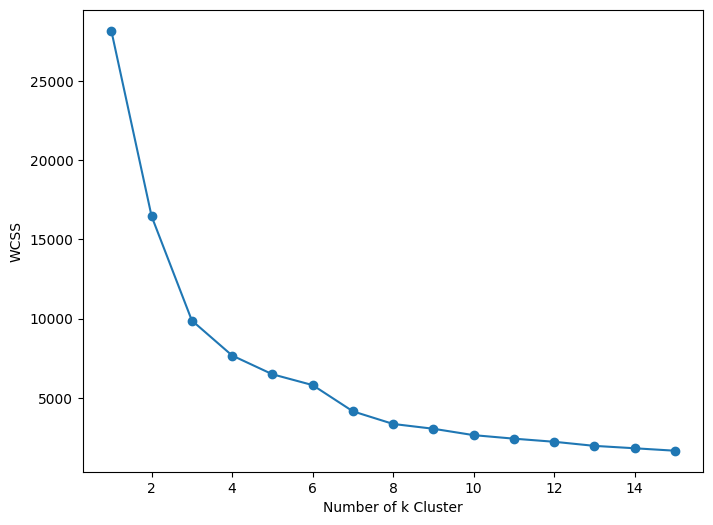

In [ ]:
from sklearn.cluster import KMeans
wcss=[]
for k in range(1,16):
  kmeans=KMeans(n_clusters=k,random_state=42)
  kmeans.fit(scaled_data)
  wcss.append(kmeans.inertia_)
  plt.figure(figsize=(8,6))
plt.plot(range(1,16),wcss,marker='o')
plt.xlabel('Number of k Cluster')
plt.ylabel("WCSS")
plt.show()

In [ ]:
kmeans=KMeans(n_clusters=3,random_state=42)

In [ ]:
clusters=kmeans.fit_predict(scaled_data)

In [ ]:
segmentation_data['Cluster']=clusters

In [ ]:
segmentation_data

,Tenure Months,Monthly charges,Total Charges,Churn Probablity,Cluster
0,2,53.85,108.15,0.866667,2
1,2,70.70,151.65,0.916667,2
2,8,99.65,820.50,0.946667,2
3,28,104.80,3046.05,0.830000,2
4,49,103.70,5036.30,0.866667,0
...,...,...,...,...,...
7038,72,21.15,1419.40,0.000000,1
7039,24,84.80,1990.50,0.006667,1
7040,72,103.20,7362.90,0.010000,0
7041,11,29.60,346.45,0.033333,1


In [ ]:
cluster_summary=segmentation_data.groupby('Cluster').mean()

In [ ]:
cluster_summary

,Tenure Months,Monthly charges,Total Charges,Churn Probablity
Cluster,,,,
0,58.101975,90.301723,5231.525999,0.110605
1,25.268615,44.040385,965.758692,0.042687
2,11.991955,72.028775,945.804981,0.904150


In [ ]:
cluster_names={
    0:'Budget loyal Customer',
    1:'High risk new customers',
    2:'Loyal premium customers'
}

In [ ]:
segmentation_data['Cluster Segment']=segmentation_data['Cluster'].map(cluster_names)

In [ ]:
segmentation_data

,Tenure Months,Monthly charges,Total Charges,Churn Probablity,Cluster,Cluster Segment
0,2,53.85,108.15,0.866667,2,Loyal premium customers
1,2,70.70,151.65,0.916667,2,Loyal premium customers
2,8,99.65,820.50,0.946667,2,Loyal premium customers
3,28,104.80,3046.05,0.830000,2,Loyal premium customers
4,49,103.70,5036.30,0.866667,0,Budget loyal Customer
...,...,...,...,...,...,...
7038,72,21.15,1419.40,0.000000,1,High risk new customers
7039,24,84.80,1990.50,0.006667,1,High risk new customers
7040,72,103.20,7362.90,0.010000,0,Budget loyal Customer
7041,11,29.60,346.45,0.033333,1,High risk new customers


<Axes: xlabel='Tenure Months', ylabel='Monthly charges'>

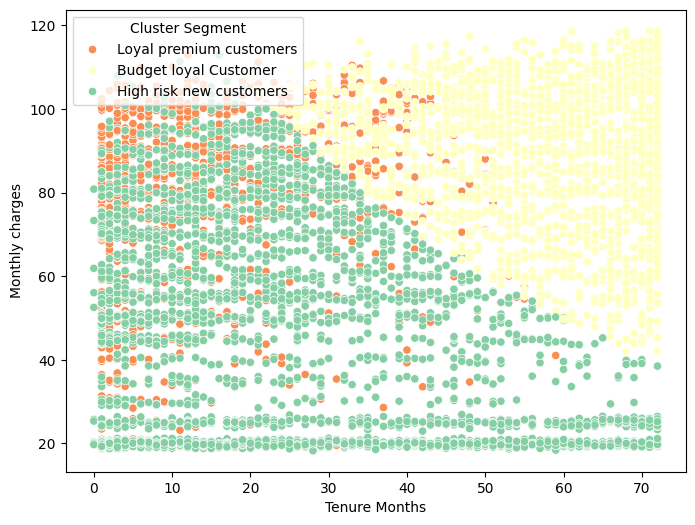

In [ ]:
plt.figure(figsize=(8,6))
sns.scatterplot(x='Tenure Months',y='Monthly charges',hue='Cluster Segment',data=segmentation_data,palette='Spectral')

<Axes: xlabel='Total Charges', ylabel='Churn Probablity'>

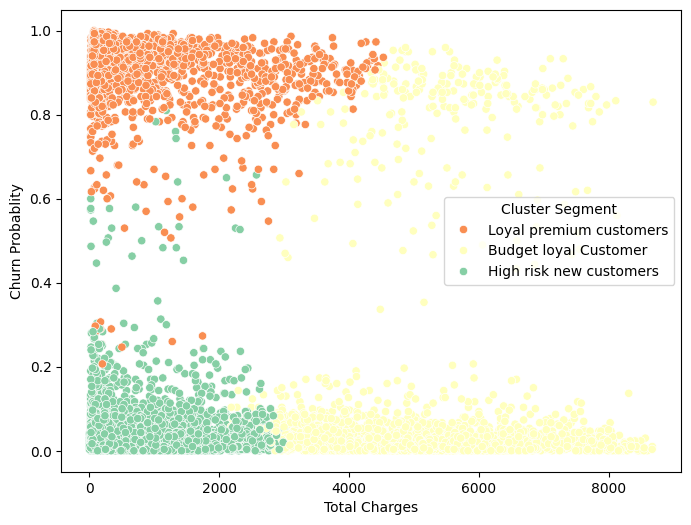

In [ ]:
plt.figure(figsize=(8,6))
sns.scatterplot(x='Total Charges',y='Churn Probablity',hue='Cluster Segment',data=segmentation_data,palette='Spectral')